# Model Graphs

Four illustrative figures for the theoretical framework (supply-shock model).

- **Fig 1** `fig_preai.png` — pre-AI wage schedule
- **Fig 2** `fig_postai.png` — post-AI shock: supply dilution vs output expansion
- **Fig 3** `fig_capability.png` — increasing AI capability: expanding the frontier
- **Fig 4** `fig_multiple.png` — non-monotone AI supply: scattered wage compression

Output to `../output/model/`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import os

os.makedirs('../output/model', exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
sigma    = 2.0            # CES elasticity of substitution
a, b     = 0.4, 0.6       # p0(i) = a + b*i  (illustration)
I_star   = 0.4            # AI capability frontier (baseline)
s_bar    = 3.0            # AI supply scale (baseline)

i_fine = np.linspace(0, 1, 2000)   # dense grid for numerical integration

def p0(i):
    """Pre-AI wage schedule (illustration: linearly increasing)."""
    return a + b * np.asarray(i, dtype=float)

# ── Derive human supply f(i) from p0 ──────────────────────────────────────────
# From p0(i) = P_Y * (Y0/f(i))^{1/sigma}, normalise Y0 = 1.
# Consistency condition: P_Y = [integral p0^{1-sigma} di]^{-1/(sigma-1)}
P_Y = np.trapz(p0(i_fine)**(1 - sigma), i_fine)**(-1 / (sigma - 1))

def f_human(i):
    """Human labour supply consistent with p0, P_Y, Y0 = 1."""
    return (P_Y / p0(i))**sigma

# ── AI supply ─────────────────────────────────────────────────────────────────
def s_ai(i, I_s=None, s_b=None):
    """AI supply: s_bar * max(0, 1 - i/I*), decreasing to 0 at I*."""
    i = np.asarray(i, dtype=float)
    if I_s is None: I_s = I_star
    if s_b is None: s_b = s_bar
    return s_b * np.maximum(0.0, 1.0 - i / I_s)

# ── Post-AI equilibrium ──────────────────────────────────────────────────────
def compute_postai(s_func):
    """Compute Ybar and post-AI wage p1 for a given AI supply function.

    Uses np.trapz on i_fine (no scipy).
    """
    ybar_vals = f_human(i_fine) + s_func(i_fine)
    int_Y = np.trapz(ybar_vals**((sigma - 1) / sigma), i_fine)
    Ybar  = int_Y**(sigma / (sigma - 1))
    def p1(i):
        yb = f_human(i) + s_func(i)
        return P_Y * (Ybar / yb)**(1 / sigma)
    return Ybar, p1

Ybar, p1 = compute_postai(s_ai)
print(f'sigma={sigma},  I*={I_star},  s_bar={s_bar}')
print(f'P_Y={P_Y:.4f},  Ybar/Y0={Ybar:.4f}')
print(f'Output expansion: (Ybar/Y0)^(1/sigma) = {Ybar**(1/sigma):.4f}')

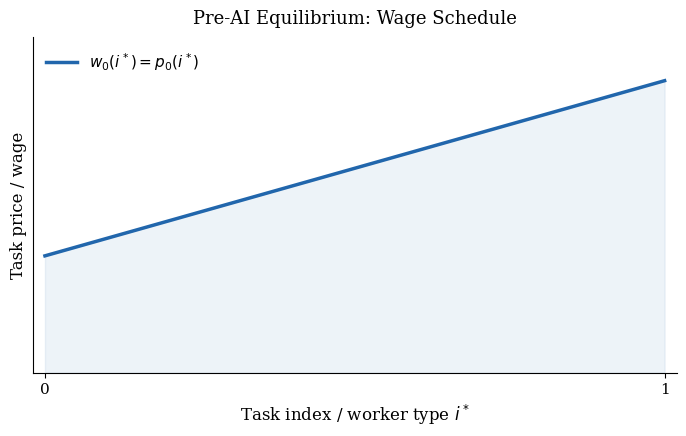

Saved fig_preai.png


In [ ]:
# ── Figure 1: Pre-AI Equilibrium ──────────────────────────────────────────────
i = np.linspace(0, 1, 300)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(i, p0(i), color='#2166ac', lw=2.5,
        label=r'$w_0(i^*) = p_0(i^*)$')
ax.fill_between(i, 0, p0(i), alpha=0.08, color='#2166ac')

ax.set_xlabel(r'Task index / worker type $i^*$', fontsize=12)
ax.set_ylabel('Task price / wage', fontsize=12)
ax.set_title('Pre-AI Equilibrium: Wage Schedule', fontsize=13, pad=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1.15)
ax.set_xticks([0, 1])
ax.set_yticks([])
ax.legend(fontsize=11, framealpha=0, loc='upper left')

plt.tight_layout()
plt.savefig('../output/model/fig_preai.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_preai.png')

In [ ]:
# ── Figure 2: Post-AI Supply Shock ────────────────────────────────────────────
i = np.linspace(0, 1, 300)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(i, p0(i), color='#2166ac', lw=2.5, ls='--',
        label=r'Pre-AI wage $p_0(i)$')
ax.plot(i, p1(i), color='#1a9641', lw=2.5,
        label=r'Post-AI wage $p_1(i)$')

# Cutoff line and AI-supplied region
ax.axvline(I_star, color='#555555', lw=1.2, ls='--')
ax.fill_betweenx([0, 1.5], 0, I_star, alpha=0.06, color='#d73027')
ax.text(I_star * 0.5, 1.38, 'AI-supplied', ha='center',
        fontsize=10, color='#d73027', fontstyle='italic')
ax.annotate(r'$I^*$', xy=(I_star, 0), xytext=(I_star + 0.01, -0.09),
            ha='left', fontsize=13, color='#555555',
            annotation_clip=False)

# Supply-dilution arrow (below I*, p1 < p0)
i_dil      = 0.10
w_pre_dil  = float(p0(i_dil))
w_post_dil = float(p1(i_dil))
ax.annotate('', xy=(i_dil, w_post_dil), xytext=(i_dil, w_pre_dil),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.text(i_dil + 0.02, (w_pre_dil + w_post_dil) / 2,
        'supply dilution', fontsize=9, va='center', ha='left')

# Output-expansion arrow (above I*, p1 > p0)
i_exp      = 0.78
w_pre_exp  = float(p0(i_exp))
w_post_exp = float(p1(i_exp))
ax.annotate('', xy=(i_exp, w_post_exp), xytext=(i_exp, w_pre_exp),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.text(i_exp + 0.02, (w_pre_exp + w_post_exp) / 2,
        'output expansion', fontsize=9, va='center', ha='left')

ax.set_xlabel(r'Task index / worker type $i^*$', fontsize=12)
ax.set_ylabel('Task price / wage', fontsize=12)
ax.set_title('Post-AI Shock: Supply Dilution vs Output Expansion',
             fontsize=13, pad=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1.5)
ax.set_xticks([0, 1])
ax.set_yticks([])
ax.legend(fontsize=10, framealpha=0, loc='lower right')

plt.tight_layout()
plt.savefig('../output/model/fig_postai.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_postai.png')

In [ ]:
# ── Figure 3: Increasing AI Capability ────────────────────────────────────────
I_stars     = [0.2, 0.4, 0.6]
cap_colors  = ['#c45000', '#d73027', '#7b0000']
cap_labels  = [
    r'$I^*=0.2$ (early AI)',
    r'$I^*=0.4$',
    r'$I^*=0.6$ (advanced AI)',
]
I_labels    = [r'$I^*_1$', r'$I^*_2$', r'$I^*_3$']

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(i, p0(i), color='#2166ac', lw=2.5,
        label=r'Pre-AI wage $p_0(i)$', zorder=5)

for I_s, color, lbl in zip(I_stars, cap_colors, cap_labels):
    s_func = lambda x, _Is=I_s: s_ai(x, I_s=_Is)
    _, p1_k = compute_postai(s_func)
    ax.plot(i, p1_k(i), color=color, lw=1.8, ls='--', label=lbl)
    ax.axvline(I_s, color=color, lw=1.0, ls=':', alpha=0.8)

# Label cutoffs below x-axis
for k, I_s in enumerate(I_stars):
    ax.annotate(I_labels[k], xy=(I_s, 0), xytext=(I_s, -0.10),
                ha='center', fontsize=11, color=cap_colors[k],
                annotation_clip=False)

# Arrow indicating direction of increasing I*
ax.annotate('', xy=(0.65, 0.25), xytext=(0.15, 0.25),
            arrowprops=dict(arrowstyle='->', color='#7b0000', lw=1.5))
ax.text(0.40, 0.30, r'increasing $I^*$',
        fontsize=10, color='#7b0000', ha='center')

ax.set_xlabel(r'Task index / worker type $i^*$', fontsize=12)
ax.set_ylabel('Task price / wage', fontsize=12)
ax.set_title(r'Increasing AI Capability: Expanding the Frontier',
             fontsize=13, pad=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1.5)
ax.set_xticks([0, 1])
ax.set_yticks([])
ax.legend(fontsize=10, framealpha=0, loc='upper left')

plt.tight_layout()
plt.savefig('../output/model/fig_capability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_capability.png')

In [ ]:
# ── Figure 4: Non-Monotone AI Supply ──────────────────────────────────────────
def s_nonmono(i):
    """Non-monotone AI supply: routine peak + complex-task pocket."""
    i = np.asarray(i, dtype=float)
    base = 2.5 * np.maximum(0, 1 - i / 0.3)          # routine tasks
    bump = 2.0 * np.exp(-((i - 0.65) / 0.06)**2)      # pocket at i~0.65
    return base + bump

Ybar_nm, p1_nm = compute_postai(s_nonmono)

fig, ax = plt.subplots(figsize=(7, 4.5))

p0_vals   = p0(i)
p1nm_vals = p1_nm(i)

ax.plot(i, p0_vals,   color='#2166ac', lw=2.5, ls='--',
        label=r'Pre-AI wage $p_0(i)$')
ax.plot(i, p1nm_vals, color='#1a9641', lw=2.5,
        label=r'Post-AI wage $p_1(i)$')

# Shade wage-compression regions (where p1 < p0)
ax.fill_between(i, p1nm_vals, p0_vals,
                where=(p1nm_vals < p0_vals),
                alpha=0.15, color='#d73027',
                label='wage compression')

# Shade wage-gain regions (where p1 > p0)
ax.fill_between(i, p0_vals, p1nm_vals,
                where=(p1nm_vals > p0_vals),
                alpha=0.10, color='#4575b4',
                label='wage gain')

# Inset: show s(i) shape
ax_in = ax.inset_axes([0.05, 0.62, 0.32, 0.30])
ax_in.fill_between(i, 0, s_nonmono(i), alpha=0.25, color='#d73027')
ax_in.plot(i, s_nonmono(i), color='#d73027', lw=1.5)
ax_in.set_title(r'$s(i)$', fontsize=9, pad=2)
ax_in.set_xlim(0, 1)
ax_in.set_xticks([0, 1])
ax_in.set_yticks([])
ax_in.tick_params(labelsize=8)
for sp in ['top', 'right']:
    ax_in.spines[sp].set_visible(False)

ax.set_xlabel(r'Task index / worker type $i^*$', fontsize=12)
ax.set_ylabel('Task price / wage', fontsize=12)
ax.set_title(r'Non-Monotone AI Supply: Scattered Wage Compression',
             fontsize=13, pad=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1.5)
ax.set_xticks([0, 1])
ax.set_yticks([])
ax.legend(fontsize=9, framealpha=0, loc='lower right')

plt.tight_layout()
plt.savefig('../output/model/fig_multiple.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_multiple.png')